In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [66]:
df = pd.read_csv("../extraction/assignmentsRaw.csv", sep=";")

df

,id,startDate,endDate,assignee,clients,admin-packet,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,isFirstAssignment,billed
0,e88cdba8-fdb5-e9fe-635b-5edea54631e1,20160914000000,20170405000000,e44f66ba-7109-798d-a7b6-9b3c7f311967,e66b5fc6-1eb7-e558-8cfa-c21b59627cca,Sonstige,False,False,False,False,False,NaN
1,5b5db4fe-beca-f2a4-466c-46d83ea6837c,20161012000000,20170111000000,76715853-3f04-fb22-4148-56e0c9f99c06,a360b954-c224-9fed-8683-61ba4e96c82d,CD Perle,False,False,False,False,False,NaN
2,a04ab468-fe04-e7c6-f2fd-f9a23bda6a0b,20161025000000,20170110000000,3a128675-bd76-5d3f-08d4-ada5ce463d51,5ce3d5ab-c86e-e2be-f4e3-3e75985e0460,Sonstige,True,True,True,True,False,NaN
3,bc0ae33d-566c-4e19-0984-2dd733df5e35,20161102000000,20170104000000,2bb3d415-9e79-64f0-209a-026b5822455d,6fd526ac-4f30-143a-7f01-c529f01d6dc8,Sonstige,False,False,False,False,False,NaN
4,51519ea1-35ab-003a-29ac-6c404cc3e020,20161115000000,20170104000000,6cb49891-0fd8-3a44-eb29-2aa3e5921989,c90a9bad-6c54-d3c6-2974-3008ab5de4ce,Basis,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95032,84602d84-e417-acd2-d98d-fe4c5ebe6500,20251231000000,20260105000000,beb5d192-4716-4aa7-ac79-35f5b8ca4b91,ef44d2f1-6d03-8f5a-66fe-d840e6526c76,Basis,True,True,True,True,True,2.026010e+13
95033,9ecfb5dc-84cb-71d7-0fdf-4e5b36e86178,20251231000000,20260114000000,1c739629-318f-912e-7eea-5b6879262b15,72443d68-685f-314b-40f6-5d46f696285e,Klassik,True,True,True,True,False,2.026011e+13
95034,ae2715c4-bcbc-adea-f59e-2900b76e567c,20251231000000,20260114000000,20feff67-405f-66b5-110d-b976007bb3de,091a7272-cbe2-b901-f4c9-f9e8d3594657,Klassik,True,True,True,True,False,2.026011e+13
95035,c840d4d3-9a05-ce3e-9ee5-9d7fc6f0eb42,20251231000000,20260127000000,30a07889-1528-355f-fbaf-76090e46a64a,d9e0d3ec-5869-2c3c-3651-c07ba85ad09e,Klassik,False,False,False,False,False,2.026013e+13


In [67]:
def eda_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "count": df.count(),
        "missing": df.isna().sum(),
        "missing_%": df.isna().mean() * 100,
        "unique": df.nunique(dropna=True),
    })

    summary["min"] = df.select_dtypes(include="number").min()
    summary["mean"] = df.select_dtypes(include="number").mean()
    summary["median"] = df.select_dtypes(include="number").median()
    summary["max"] = df.select_dtypes(include="number").max()

    return summary.round(2)

summary = eda_summary(df)
summary

,dtype,count,missing,missing_%,unique,min,mean,median,max
id,object,95037,0,0.00,95037,NaN,NaN,NaN,NaN
startDate,int64,95037,0,0.00,2816,2.016091e+13,2.021678e+13,2.022082e+13,2.025123e+13
endDate,int64,95037,0,0.00,3143,2.017010e+13,2.021754e+13,2.022092e+13,2.027011e+13
assignee,object,95037,0,0.00,7744,NaN,NaN,NaN,NaN
clients,object,95037,0,0.00,6968,NaN,NaN,NaN,NaN
admin-packet,object,80935,14102,14.84,14,NaN,NaN,NaN,NaN
arrivalSelfOrganized,bool,95037,0,0.00,2,NaN,NaN,NaN,NaN
departureSelfOrganized,bool,95037,0,0.00,2,NaN,NaN,NaN,NaN
arrivalNoBilling,bool,95037,0,0.00,2,NaN,NaN,NaN,NaN
departureNoBilling,bool,95037,0,0.00,2,NaN,NaN,NaN,NaN


In [68]:
df_dropped = df.drop(columns= summary[summary["missing"]>0].index)

In [69]:

df_dropped["startDate"] = pd.to_datetime(
    df_dropped["startDate"].astype("string"),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df_dropped["endDate"] = pd.to_datetime(
    df_dropped["endDate"].astype("string"),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)


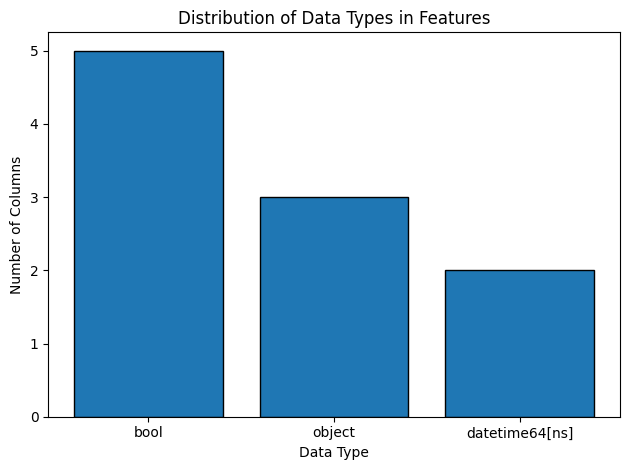

In [70]:
summary = eda_summary(df_dropped)

dtypes = summary["dtype"].astype(str).value_counts()

plt.bar(
    dtypes.index,
    dtypes.values,
    edgecolor="black"
)

plt.title("Distribution of Data Types in Features")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.yticks(
    np.arange(0, 6, 1)
)

plt.tight_layout()
plt.show()

                        nunique  most_common_pct
isFirstAssignment             2        94.725212
arrivalNoBilling              2        66.569862
departureNoBilling            2        66.414133
arrivalSelfOrganized          2        65.360859
departureSelfOrganized        2        64.347570
assignee                   7744         0.275682
clients                    6968         0.249377
startDate                  2816         0.202027
endDate                    3143         0.152572
id                        95037         0.001052


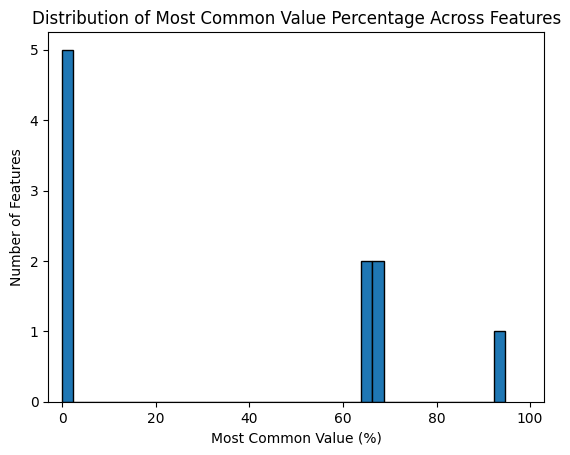

In [71]:
feature_summary = pd.DataFrame({
    "nunique": df_dropped.nunique(),
    "most_common_pct": df_dropped.apply(
        lambda col: col.value_counts(normalize=True, dropna=False).iloc[0] * 100
    )
})

print(feature_summary.sort_values("most_common_pct", ascending=False))

plt.hist(
    feature_summary["most_common_pct"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Most Common Value Percentage Across Features")
plt.xlabel("Most Common Value (%)")
plt.ylabel("Number of Features")

plt.xticks(np.arange(0, 101, 20))

# Add a little visual space after 100
plt.xlim(-3, 103)

plt.show()

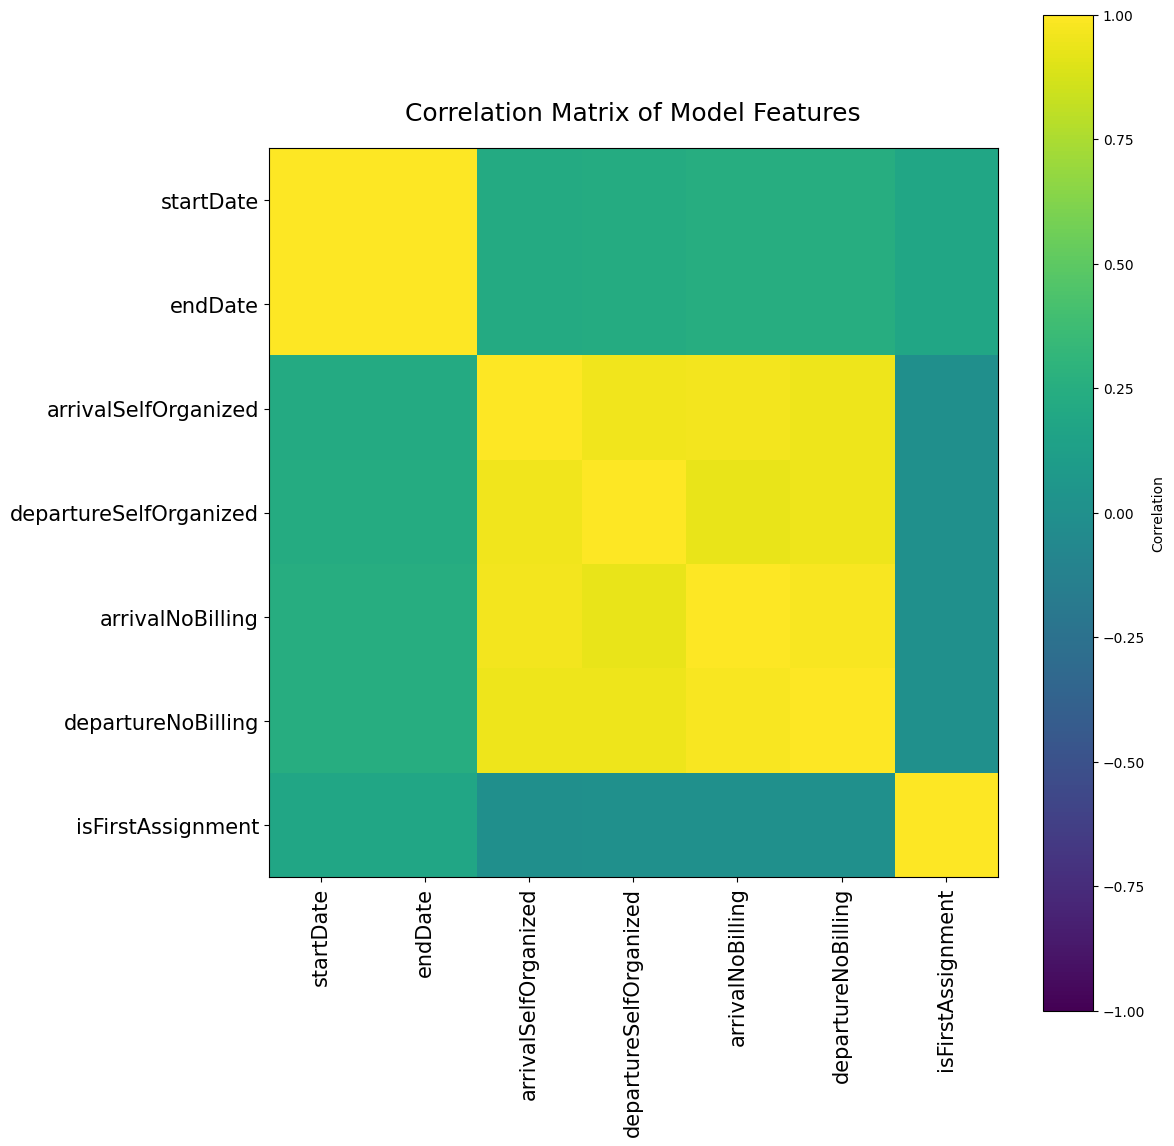

In [72]:
corr = df_dropped.drop(columns=["id", "assignee", "clients"]).corr()

# Hide upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dynamic figure size
n_features = len(corr.columns)
figsize = max(12, n_features * 0.45)

fig, ax = plt.subplots(figsize=(figsize, figsize))


im = ax.imshow(
    corr,
    vmin=-1,
    vmax=1,
    aspect="equal"
)

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))

ax.set_xticklabels(
    corr.columns,
    rotation=90,
    fontsize=15
)

ax.set_yticklabels(
    corr.columns,
    fontsize=15
)

ax.set_title(
    "Correlation Matrix of Model Features",
    fontsize=18,
    pad=20
)

plt.tight_layout()
plt.show()

In [73]:
colsToCombine = [
    "arrivalSelfOrganized",
	"departureSelfOrganized",
	"arrivalNoBilling",
	"departureNoBilling"
]

colsToCombine


df_dropped["selfOrganized"] = (
    df_dropped[colsToCombine]
    .mean(axis=1)
    .round()
)


df_toExport = df_dropped.drop(columns=colsToCombine)

In [74]:
df_toExport.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95037 entries, 0 to 95036
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 95037 non-null  object        
 1   startDate          95037 non-null  datetime64[ns]
 2   endDate            95037 non-null  datetime64[ns]
 3   assignee           95037 non-null  object        
 4   clients            95037 non-null  object        
 5   isFirstAssignment  95037 non-null  bool          
 6   selfOrganized      95037 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(1), object(3)
memory usage: 4.4+ MB


In [75]:
df_toExport.to_csv("assignments.csv", sep=";", index=False)